In [4]:
import os

DATA_ROOT = "/kaggle/input/datasets/ramansss/vt-ph-reg/flickr30k-images"

files = os.listdir(DATA_ROOT)
print("Number of images:", len(files))
print("Sample files:", files[:5])


Number of images: 31784
Sample files: ['2715746315.jpg', '3463034205.jpg', '268704620.jpg', '2673564214.jpg', '7535037918.jpg']


In [ ]:
!pip install -q open-clip-torch==2.31.0
!pip install -q transformers==4.37.2
!pip install -q timm accelerate diffusers
!pip install -q numpy==1.26.4
!pip install -q scikit-image scikit-learn imageio opencv-python

In [6]:
import torch
# import open_clip
import numpy as np

print("Torch:", torch.__version__)
print("OpenCLIP OK")
print("Numpy:", np.__version__)
print("CUDA:", torch.cuda.is_available())


Torch: 2.9.0+cu126
OpenCLIP OK
Numpy: 2.0.2
CUDA: True


In [7]:
!git clone https://github.com/0raiser0/PH-Reg.git


Cloning into 'PH-Reg'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 361 (delta 55), reused 64 (delta 23), pack-reused 255 (from 2)
Receiving objects: 100% (361/361), 23.71 MiB | 32.99 MiB/s, done.
Resolving deltas: 100% (112/112), done.


In [8]:
!ls PH-Reg


CLIP  DINOv2_full  images  LICENSE  README.md  requirements_eval.txt


In [9]:
%cd PH-Reg


/kaggle/working/PH-Reg


In [ ]:
!pip install -q -r requirements_eval.txt
!pip install -q matplotlib scipy scikit-image scikit-learn h5py
!pip install -q open-clip-torch==2.31.0

In [11]:
%cd /kaggle/working/PH-Reg


/kaggle/working/PH-Reg


In [12]:
%cd /kaggle/working/PH-Reg/CLIP


/kaggle/working/PH-Reg/CLIP


In [13]:
!ls


datasets  distill_main.py  models  utils  visualization.ipynb  zero_shot


In [14]:
import sys
sys.path.insert(0, "/kaggle/working/PH-Reg/CLIP")
print(sys.path[0])


/kaggle/working/PH-Reg/CLIP


In [15]:
import torch
import open_clip

from models import *
from datasets import *
from utils import *

print("PH-Reg CLIP imports working ✅")


PH-Reg CLIP imports working ✅


In [16]:
import torch
torch.cuda.empty_cache()


In [17]:
!pwd

/kaggle/working/PH-Reg/CLIP


In [19]:
import torch
torch.cuda.empty_cache()


In [20]:
!mkdir -p /kaggle/working/flickr30k_images_clean
!rsync -av --exclude='*.txt' /kaggle/input/vt-ph-reg/flickr30k-images/ /kaggle/working/flickr30k_images_clean/


sending incremental file list
rsync: [sender] change_dir "/kaggle/input/vt-ph-reg/flickr30k-images" failed: No such file or directory (2)

sent 19 bytes  received 12 bytes  62.00 bytes/sec
total size is 0  speedup is 0.00
rsync error: some files/attrs were not transferred (see previous errors) (code 23) at main.c(1338) [sender=3.2.7]


In [ ]:
#!ls /kaggle/working/flickr30k_images_clean | head


In [21]:
from pathlib import Path

file_path = Path("/kaggle/working/PH-Reg/CLIP/distill_main.py")
text = file_path.read_text()

# Replace DataLoader block safely
text = text.replace(
    "train_dataloader = DataLoader(\n"
    "        dataset=train_set,\n"
    "        batch_size=args_dict['batch_size'],\n"
    "        shuffle=shuffle,\n"
    "        drop_last=True,\n"
    "        num_workers=8\n"
    "    )",
    "train_dataloader = DataLoader(\n"
    "        dataset=train_set,\n"
    "        batch_size=args_dict['batch_size'],\n"
    "        shuffle=shuffle,\n"
    "        drop_last=True,\n"
    "        num_workers=4,\n"
    "        pin_memory=True,\n"
    "        persistent_workers=True\n"
    "    )"
)

file_path.write_text(text)
print("✅ DataLoader updated: num_workers=4, pin_memory=True")


✅ DataLoader updated: num_workers=4, pin_memory=True


In [ ]:
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \
python distill_main.py \    # type: ignore
  --data_root /kaggle/working/flickr30k_images_clean \   # type: ignore
  --save_dir /kaggle/working/phreg_clip_ckpt \  # type: ignore
  --pretrained_path ViT-B/16 \ # type: ignore
  --resolution 192 \  # type: ignore
  --batch_size 1 \   # type: ignore
  --counts 2 \       # type: ignore
  --num_of_reg 8 \   # type: ignore
  --num_epochs 3 \  # type: ignore
  --lr 1e-4 \      # type: ignore
  --end_lr 1e-5    # type: ignore

In [23]:
%cd /kaggle/working/PH-Reg/CLIP
!ls


/kaggle/working/PH-Reg/CLIP
datasets  distill_main.py  models  utils  visualization.ipynb  zero_shot


In [24]:
%cd /kaggle/working/PH-Reg/CLIP


/kaggle/working/PH-Reg/CLIP


In [25]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


In [26]:
# ===== PATHS =====
DISTILLED_PATH = (
    "/kaggle/input/open-clip/pytorch/default/V1/"
    "OpenAI_CLIP_B_16_Distilled.pth"
)

IMAGE_PATH = "/kaggle/input/vt-ph-reg/flickr30k-images/1000092795.jpg"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESOLUTION = 192
PATCH_SIZE = 16
NUM_REGISTERS = 8


In [28]:
%cd /kaggle/working/PH-Reg/CLIP

import sys
sys.path.append("/kaggle/working/PH-Reg/CLIP")
sys.path.append("/kaggle/working/PH-Reg/CLIP/models")

print("✅ Path fixed")


/kaggle/working/PH-Reg/CLIP
✅ Path fixed


In [ ]:
!pip install umap-learn numba ftfy regex tqdm

In [30]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
import umap
import numba

from PIL import Image
from torchvision import transforms


2026-03-17 17:11:08.171081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773767468.592067      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773767468.721275      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773767469.703629      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773767469.703668      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773767469.703670      55 computation_placer.cc:177] computation placer alr

In [ ]:
# /kaggle/input/open-clip/pytorch/default/1/OpenAI_CLIP_B_16_Distilled.pth
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#  your uploaded distilled model
DISTILLED_PATH = "/kaggle/input/models/ramanmankar/open-clip/pytorch/default/1/OpenAI_CLIP_B_16_Distilled.pth"

# teacher CLIP
PRETRAINED_NAME = "ViT-B/16"

RESOLUTION = 448
PATCH_SIZE = 16
NUM_PATCHES = RESOLUTION // PATCH_SIZE
NUM_REGISTERS = 16

IMG_PATH = "/kaggle/input/datasets/ramansss/vt-ph-reg/flickr30k-images/1000092795.jpg"


In [36]:
from models.NACLIP.clip import load, tokenize

clip_model, _ = load(
    name=PRETRAINED_NAME,
    device=DEVICE,
    jit=False
)

clip_model = clip_model.to(dtype=torch.float32).eval()
clip_model.visual.set_params(
    arch="reduced",
    attn_strategy="naclip",
    gaussian_std=5.0
)


In [37]:
from models.student_CLIP import StudentCLIP

student = StudentCLIP(
    pretrained=PRETRAINED_NAME,
    num_registers=NUM_REGISTERS,
    patch_size=PATCH_SIZE,
    input_resolution=(RESOLUTION, RESOLUTION)
)

ckpt = torch.load(DISTILLED_PATH, map_location="cpu")
student.load_state_dict(ckpt, strict=False)

student = student.to(DEVICE).float().eval()

print("✅ Distilled PH-Reg model loaded")


✅ Distilled PH-Reg model loaded


In [39]:
@numba.njit()
def mydist(a, b):
    return np.arccos(np.sum(a * b))


def feature_umap(patch_feats, num_patches):
    patch_feats = patch_feats / patch_feats.norm(dim=-1, keepdim=True)
    patch_feats_np = patch_feats.cpu().numpy()

    reducer = umap.UMAP(
        n_components=3,
        metric=mydist
    )

    emb = reducer.fit_transform(patch_feats_np)
    emb = emb.reshape(num_patches, num_patches, 3)

    emb = (emb - emb.min()) / (emb.max() - emb.min() + 1e-8)
    emb = torch.tensor(emb).permute(2, 0, 1).unsqueeze(0)
    emb = F.interpolate(emb, size=RESOLUTION, mode="nearest")
    return emb.squeeze().permute(1, 2, 0).numpy()


def generate_heatmap(img_feat, txt_feat):
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

    heat = torch.bmm(
        img_feat,
        txt_feat.unsqueeze(1).transpose(1, 2)
    )

    heat = heat.squeeze().reshape(NUM_PATCHES, NUM_PATCHES)
    heat = heat.unsqueeze(0).unsqueeze(0)
    heat = F.interpolate(heat, size=RESOLUTION, mode="nearest")
    return heat.squeeze().cpu().numpy()


In [43]:
img = Image.open(IMG_PATH).convert("RGB")

transform = transforms.Compose([
    transforms.Resize(RESOLUTION),
    transforms.CenterCrop(RESOLUTION),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    )
])

img_tensor = transform(img).unsqueeze(0).to(DEVICE)


In [44]:
with torch.no_grad():
    # teacher
    naclip_dense = clip_model.visual(
        img_tensor, return_all=True
    )[:, 1:, :]

    # student
    clean_dense = student(img_tensor)[:, 1+NUM_REGISTERS:, :]


In [45]:
texts = ["a photo of cats"]
text_tokens = tokenize(texts).to(DEVICE)

with torch.no_grad():
    text_feat = clip_model.encode_text(text_tokens)


In [46]:
naclip_umap = feature_umap(naclip_dense[0], NUM_PATCHES)
student_umap = feature_umap(clean_dense[0], NUM_PATCHES)

naclip_heat = generate_heatmap(naclip_dense, text_feat)
student_heat = generate_heatmap(clean_dense, text_feat)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(


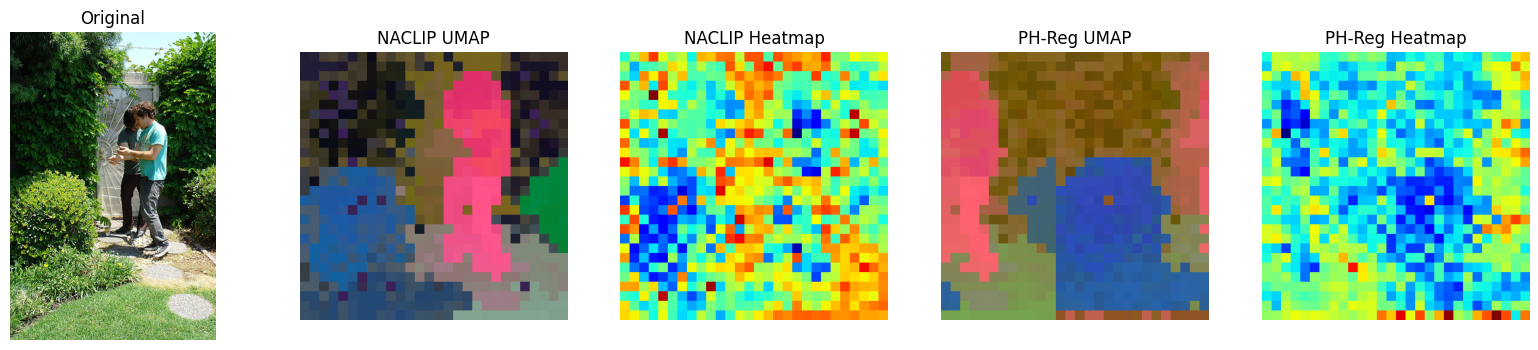

In [47]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(naclip_umap)
axes[1].set_title("NACLIP UMAP")
axes[1].axis("off")

axes[2].imshow(naclip_heat, cmap="jet")
axes[2].set_title("NACLIP Heatmap")
axes[2].axis("off")

axes[3].imshow(student_umap)
axes[3].set_title("PH-Reg UMAP")
axes[3].axis("off")

axes[4].imshow(student_heat, cmap="jet")
axes[4].set_title("PH-Reg Heatmap")
axes[4].axis("off")

plt.show()
